In [187]:
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText
from PIL import Image

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.bfloat16 if device == "cuda" else torch.float32
print("device:", device, "| dtype:", dtype)

device: cuda | dtype: torch.bfloat16


In [3]:
# !pip install "transformers[serving] @ git+https://github.com/huggingface/transformers.git@main"

In [2]:
MODEL = "Qwen/Qwen3-VL-8B-Instruct"
processor = AutoProcessor.from_pretrained(MODEL)
model = AutoModelForImageTextToText.from_pretrained(
    MODEL,
    torch_dtype=dtype,
    device_map="auto" if device == "cuda" else None,
)
if device == "cpu":
    model.to(device)
model.eval()
print("loaded", MODEL)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/750 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/269 [00:00<?, ?B/s]

loaded Qwen/Qwen3-VL-8B-Instruct


In [195]:
import random
from pathlib import Path
from PIL import Image

# HWR = Path("/mnt/DATA2/varlamova/HTR/trocr/data/texts/hwr200/filtered_lines_v2")
# LINES, TXTS = HWR / "lines", HWR / "lines_txt"

LINES = Path("/mnt/DATA2/varlamova/HTR/trocr/data/texts/hwr200/filtered_lines_v2/lines")
TXTS = Path("/mnt/DATA2/dorin/handwriting-recognition/recognition/data/lines_txt_clean")

PAIRS = [(p, TXTS / f"{p.stem}.txt") for p in sorted(LINES.glob("*.png"))
         if (TXTS / f"{p.stem}.txt").exists()]
print(len(PAIRS), "pairs")

def sample(n=1, seed=None):
    rnd = random.Random(seed)
    out = []
    for img_p, txt_p in rnd.sample(PAIRS, min(n, len(PAIRS))):
        out.append({
            "name": img_p.stem,
            "image_path": str(img_p),
            "target": txt_p.read_text(encoding="utf-8").strip(),
            "image": Image.open(img_p).convert("RGB"),
        })
    return out

50972 pairs


In [200]:
sample_ = sample()

image = sample_[0]["image"]
target = sample_[0]["target"]

In [201]:
sample_[0]["image_path"]

'/mnt/DATA2/varlamova/HTR/trocr/data/texts/hwr200/filtered_lines_v2/lines/28_reuse9_ФотоСветлое_2_0003.png'

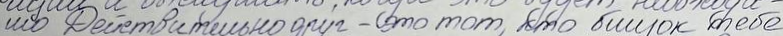

In [202]:
image

In [203]:
target

'Действительно друг - это тот, кто близок тебе'

In [193]:
SYSTEM = (
    "Ты корректируешь OCR-расшифровку рукописной русской строки. "
    "Тебе дают картинку ОДНОЙ рукописной строки и её черновую расшифровку. "
    "Расшифровка обычно почти верна — меняй минимум, только явные ошибки распознавания. "
    "Типичные ошибки, которые надо чинить: "
    "часть текста пропущена (обычно слово или кусок слова в начале/конце строки), "
    "хотя на картинке он есть, — его надо дописать ровно так, как видно на картинке. "
    "Используй только допустимые символы: русские буквы (включая ё/Ё), цифры 0–9 и знаки "
    "«пробел . , ! ? ; : - — ( ) « » \" ' / % №». "
    "Никаких других символов (латиницы, квадратных скобок [ ], эмодзи, спецзнаков) в ответе быть не должно. "
    "Выведи ТОЛЬКО итоговую строку."
)

# SYSTEM = (
#     "Ты корректируешь OCR-расшифровку ОДНОЙ рукописной русской строки. "
#     "Тебе дают картинку этой строки и её черновую расшифровку; расшифровка обычно почти верна. "
#     "Типичные ошибки, которые надо чинить, два вида:\n"
#     "1) В начале или в конце расшифровки приклеены лишние куски слов, «переехавшие» с соседней "
#     "(предыдущей или следующей) строки, — их на этой картинке нет. Такие чужие фрагменты надо убрать.\n"
#     "2) Наоборот, часть текста пропущена (обычно слово или кусок слова в начале/конце строки), "
#     "хотя на картинке он есть, — его надо дописать ровно так, как видно на картинке.\n"
#     "Правь ТОЛЬКО это. В остальном меняй минимум. "
#     "Не удаляй и не переписывай знаки или слова, если ты в их ошибочности уверен лишь поверхностно — "
#     "при сомнении оставляй как в черновике. Убирай фрагмент только когда явно видно, что он с другой строки; "
#     "дописывай только то, что отчётливо читается на картинке. "
#     "Сохраняй пунктуацию, регистр и завершающий перенос-дефис. "
#     "Выведи ТОЛЬКО итоговую строку, без кавычек и пояснений."
# )

def make_prompt(target):
    return (
        "Черновая расшифровка строки:\n"
        f"{target}\n\n"
        "Сверь её с картинкой и верни итоговую строку.\n"
        "Правила:\n"
        "- Это ОДНА строка; сохрани пунктуацию, регистр, пробелы и завершающий дефис, если он есть.\n"
        "- Исправляй только символы/слова, в которых ты уверен по картинке.\n"
        "- Если фрагмент неразборчив — оставь как в черновике.\n"
        "- Не переписывай, не перефразируй, не дополняй, не переводи.\n"
        "- Выведи ТОЛЬКО итоговую строку, без кавычек и пояснений."
    )

In [204]:
img = image
if img.height < 112:                      # апскейл тонкой строки — VLM лучше видит
    s = 112 / img.height
    img = img.resize((max(1, int(img.width * s)), 112))

messages = [
    {"role": "system", "content": SYSTEM},
    {"role": "user", "content": [
        {"type": "image", "image": img},
        {"type": "text", "text": make_prompt(target)},
    ]},
]
kw = dict(add_generation_prompt=True, tokenize=True, return_dict=True, return_tensors="pt")
inputs = processor.apply_chat_template(messages, **kw).to(model.device)

out = model.generate(**inputs, max_new_tokens=160, do_sample=False)
raw = processor.decode(out[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True)
lines = [ln.strip().strip('"') for ln in raw.splitlines() if ln.strip()]
print("OCR  :", target)
print("FIXED:", lines[-1] if lines else "")

OCR  : Действительно друг - это тот, кто близок тебе
FIXED: Действительно друг — это тот, кто близок тебе


### English-Handwritten-Math-Notes-Dataset

In [1]:
from datasets import load_dataset
ds = load_dataset("HumynLabs/English-Handwritten-Math-Notes-Dataset")
print(ds)
ds["train"].features

Resolving data files:   0%|          | 0/100 [00:00<?, ?it/s]

DatasetDict({
    train: Dataset({
        features: ['pdf'],
        num_rows: 100
    })
})


{'pdf': Pdf(decode=True)}

In [2]:
# !pip install pdfplumber